In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 2** - Mystery ML model

- Model takes two numbers as input and returns a log-likelihood score.
  - **Goal** - maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.

- **Method of tackling this problem** - Bayesian optimisation, which selects the next inputs based on what it has learned so far.
  - I will aim to balance exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

- **Process and thinking** - use probability of improvement (PI) to exploit the area around our current best discovery.


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_2\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_2\initial_outputs.npy')

In [ ]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.638512, 0.014290], dtype=np.float64)
Y_w1_new_point = np.array([0.29668333272205905], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w1_new_point))
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)
Y_updated = np.append(Y, Y_w1_new_point)[unique_indices]

# Save the updated arrays
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_2\initial_inputs.npy', X_unique)
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_2\initial_outputs.npy', Y_updated)

In [8]:
# Show updated arrays
print("Updated Inputs (X) - Function 2: ", X_unique)
print("Updated Outputs (Y) - Function 2: ", Y_updated)

Updated Inputs (X) - Function 2:  [[0.14269907 0.34900513]
 [0.33864816 0.21386725]
 [0.34174959 0.02869772]
 [0.43816606 0.68501826]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.638512   0.01429   ]
 [0.66579958 0.12396913]
 [0.70263656 0.9265642 ]
 [0.84527543 0.71112027]
 [0.87779099 0.7786275 ]]
Updated Outputs (Y) - Function 2:  [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.53899612  0.61120522  0.29399291  0.42058624]


### **Interpreation of the Output and Potential Next steps to improve the model**


- We have found a region with low probability - output = 0.297.
  - In a log-likelihood context, this is a pretty weak starting point that hasn't yet reached near a local or global peak.

- What this means for the next step is that we need to move away from the random search strategy that I went for in Week 1 to a more strategic Gaussian Process Model with a Expected Improvement (EI) surrogate model, as breifly outlined in week 1 strategic approach.
  - By using this surrogate model we can map out which point is strategically going to help us find a global and local optimum, rather than a random search which wasn't very useful.


### **Bayesian Optimisation** - Gaussian Processess using RBF kernel


- Initially I am sticking with the RBF kernel, as it often works better for smaller deminsional functions.
  - I believe that if the RBF kernel doesn't work as well as I expect it to work I will swtich to a Mattern kerenel however, I know that Matern is usually better of in a 4D+ scenario.

- I create a noise assumption which is a standard 0.01 and I will play around with this as we move forward in the exploration stages.


In [9]:
noise_assumption = 0.01

In [ ]:
kernel = RBF(length_scale=1.0)
model = GaussianProcessRegressor(
    kernel = kernel,
    alpha = noise_assumption,
    n_restarts_optimizer= 10,
)
model.fit(X_unique, Y_updated)

GaussianProcessRegressor(alpha=0.01, kernel=RBF(length_scale=1),
                         n_restarts_optimizer=10)

### **Acquisition Function** - probability of improvement

- I am using Probability of improvement as this is a function which is a mystery ML model which returns log-likelihood score which is often noisy and prone to trapping optimizers in local optima.
  - The PI can help the search jump out of a local peak if the surrounding uncertainty suggests a higher probability of finding a better point elsewhere.

- Additionally, PI helps use the Gaussian Process's predictive mean and variance to quanitfy the utility of a point before evaluating it.

- Additionally since this is only a 2D function, once a region of the global maximum is identified, PI can refine the solution by targetting the exact coordinates most likley to provide incremental improvement to the log-likelihood.


In [11]:
def probability_of_improvement(X_unique, model, y_max, eta=0.05):
    mu, sigma = model.predict(X_unique, return_std=True)
    mu = mu.reshape(-1,1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        z = (mu - y_max - eta) / sigma
        pi = norm.cdf(z)
        pi[sigma == 0.0] = 0.0
        
    return pi.ravel()

y_max = np.max(Y_updated)

# Creating 10,000 points to enhance the 2D grid search
x_grid = np.random.uniform(0, 1, size=(30000, 2))

# Evaluate the acquisition function at these points
pi_values = probability_of_improvement(x_grid, model, y_max, eta=0.05)

# Identify the point with the highest improvements
best_idx = np.argmax(pi_values)
next_query = x_grid[best_idx]

print(f"\nNext query point suggested by PI acquisition function: [{next_query[0]:.6f}, {next_query[1]:.6f}]")


Next query point suggested by PI acquisition function: [0.998312, 0.002851]


## **Visualisation of the search map and progress plot**


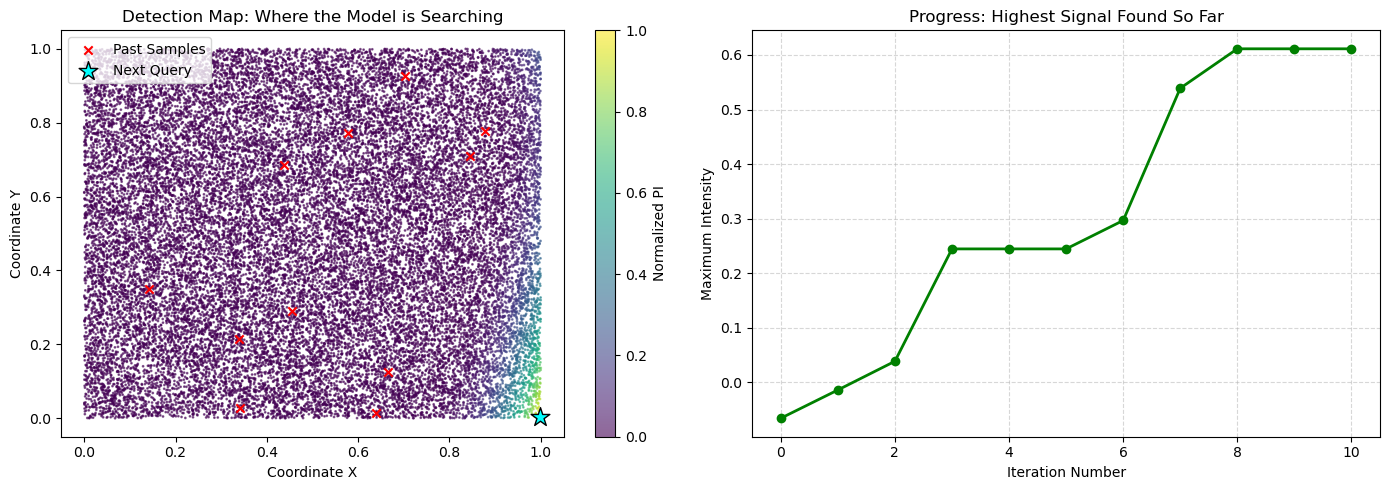

Strategic Result: Next point to query is at (0.998312-0.002851)


In [13]:
# Calculate running maximum of observed values for progress plot
running_max = np.maximum.accumulate(Y_updated)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Define the acquisition function used for plotting.
acquisition_function = pi_values
acq_norm = (acquisition_function - np.nanmin(acquisition_function)) / (np.nanmax(acquisition_function) - np.nanmin(acquisition_function) + 1e-12)

# The Search Map (Where are we looking?)
# This shows the "hot zones" the model wants to explore next.
sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='viridis', s=1, alpha=0.6)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized PI')
ax1.scatter(X_unique[:, 0], X_unique[:, 1], c='red', marker='x', label='Past Samples')
ax1.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=200, edgecolors='black', label='Next Query')
ax1.set_title('Detection Map: Where the Model is Searching')
ax1.set_xlabel('Coordinate X')
ax1.set_ylabel('Coordinate Y')
ax1.legend()

# The Progress Plot (Are we finding anything?)
# A simple line graph showing the best detection score over time.
ax2.plot(running_max, color='green', linewidth=2, marker='o')
ax2.set_title('Progress: Highest Signal Found So Far')
ax2.set_xlabel('Iteration Number')
ax2.set_ylabel('Maximum Intensity')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Strategic Result: Next point to query is at ({next_query[0]:.6f}-{next_query[1]:.6f})")